## 1. Project Overview

# ResearchRadar
### Academic Paper Semantic Search & Recommendation

<div style="padding:18px;border-radius:14px;background:#f7f8fa;border:1px solid #e5e7eb;">
<h1 style="margin:0 0 8px 0;">RESEARCHRADAR</h1>
<p style="font-size:17px;margin:0 0 14px 0;">Discover scientific literature using semantic similarity.</p>
<span style="display:inline-block;padding:6px 10px;margin:3px;border-radius:999px;background:#eef2ff;">NLP</span>
<span style="display:inline-block;padding:6px 10px;margin:3px;border-radius:999px;background:#ecfeff;">Information Retrieval</span>
<span style="display:inline-block;padding:6px 10px;margin:3px;border-radius:999px;background:#f0fdf4;">Sentence Embeddings</span>
<span style="display:inline-block;padding:6px 10px;margin:3px;border-radius:999px;background:#fff7ed;">Semantic Search</span>
<span style="display:inline-block;padding:6px 10px;margin:3px;border-radius:999px;background:#fdf2f8;">Recommendation Systems</span>
<span style="display:inline-block;padding:6px 10px;margin:3px;border-radius:999px;background:#f5f3ff;">Data Visualisation</span>
</div>

ResearchRadar is a small, end-to-end portfolio project built entirely in Google Colab. It retrieves relevant scientific abstracts from the BEIR SciFact benchmark, compares lexical and semantic retrieval, recommends similar papers using content similarity, visualises the embedding space, and evaluates retrieval against the official SciFact relevance judgements.

The central idea is intentionally simple: **text → vector → similarity → ranking → recommendation → evaluation**.



In [ ]:
from IPython.display import display, HTML
display(HTML("""<div style='text-align:center;padding:22px;border-radius:16px;border:1px solid #ddd;'>
<h2 style='margin:0;'>ResearchRadar</h2>
<p style='margin:6px 0 0;'>Academic Paper Semantic Search & Recommendation</p>
</div>"""))


## 2. Why Information Retrieval?

Information Retrieval (IR) is about finding useful documents from a larger collection in response to a user's information need. A search engine is a familiar example: the user supplies a query, the system scores documents, and the system returns an ordered list.

ResearchRadar uses two retrieval ideas side by side:

- **TF-IDF retrieval:** looks primarily at lexical overlap between a query and documents.
- **Semantic retrieval:** converts text into dense vectors and compares their meaning in an embedding space.

The important engineering lesson is that retrieval is not the same thing as generation. ResearchRadar does **not** generate answers or act as a chatbot; it returns documents from the supplied corpus.



## 3. Problem Statement

Scientific literature is large enough that exact keyword matching can miss documents that express the same idea with different terminology. ResearchRadar asks: **Can a lightweight pretrained sentence-embedding model retrieve semantically relevant scientific abstracts from SciFact, and how does that retrieval compare with a simple TF-IDF baseline?**

The recommendation component then reuses document similarity: once a paper is selected, its embedding becomes the query for finding nearby papers. This is a **content-based** recommender, not collaborative filtering, because SciFact does not provide user-rating history.



## 4. System Architecture

The architecture stays deliberately small:

```text
                         RESEARCHRADAR
                              |
                +-------------+-------------+
                |                           |
          SEMANTIC SEARCH             PAPER RECOMMENDER
                |                           |
           User Query                 Selected Paper
                |                           |
        Sentence Embedding          Sentence Embedding
                |                           |
        Cosine Similarity            Cosine Similarity
                |                           |
            Top Papers                Similar Papers
                +-------------+-------------+
                              |
                     Visual Exploration
                              |
                         IR Evaluation
                    TF-IDF | Semantic | Hybrid
```


## 5. Environment Setup

The install cell keeps dependencies focused on the actual notebook: BEIR for the benchmark, Sentence Transformers for embeddings, and the standard Python data/visualisation stack.



In [ ]:
%pip -q install -U "beir>=2.2,<3" "sentence-transformers>=3,<6" "scikit-learn>=1.5,<2" "plotly>=5,<7" "seaborn>=0.13,<1" "tqdm>=4.66,<5" "ipywidgets>=8,<9"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.9/304.9 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.7 MB/s eta 0:00:00


## 6. Import Libraries

Keeping imports in one place and the random seed is fixed for reproducible sampling/PCA.


In [ ]:
import os
import re
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from tqdm.auto import tqdm
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

from beir import util
from beir.datasets.data_loader import GenericDataLoader
from beir.retrieval.evaluation import EvaluateRetrieval

from sentence_transformers import SentenceTransformer

import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
try:
    torch.manual_seed(SEED)
except Exception:
    pass

print("Python environment ready")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Python environment ready
PyTorch version: 2.11.0+cpu
CUDA available: False


## 7. Load BEIR SciFact Dataset

SciFact is loaded using BEIR's own dataset loader. The test retrieval split gives us three things:

- `corpus`: document ID → title/text
- `queries`: query ID → scientific claim/query
- `qrels`: query ID → relevant document ID → relevance grade


In [ ]:
DATASET_NAME = "scifact"
DATA_DIR = "/content/datasets"
CACHE_DIR = Path("/content/researchradar_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

SCIFACT_URL = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{DATASET_NAME}.zip"

def load_scifact(data_dir=DATA_DIR):
    data_path = Path(data_dir) / DATASET_NAME
    corpus_path = data_path / "corpus.jsonl"

    if not corpus_path.exists():
        print("Downloading SciFact from the official BEIR dataset host...")
        util.download_and_unzip(SCIFACT_URL, data_dir)

    corpus, queries, qrels = GenericDataLoader(data_folder=str(data_path)).load(split="test")
    return corpus, queries, qrels

corpus, queries, qrels = load_scifact()
print(f"Corpus documents: {len(corpus):,}")
print(f"Test queries: {len(queries):,}")
print(f"Queries with qrels: {len(qrels):,}")


/content/datasets/scifact.zip:   0%|          | 0.00/2.69M [00:00<?, ?iB/s]

  0%|          | 0/5183 [00:00<?, ?it/s]

Corpus documents: 5,183
Test queries: 300
Queries with qrels: 300


## 8. Understand the Dataset

The benchmark uses a familiar IR structure. A document has an ID plus title/text. A query has an ID plus a scientific claim. Qrels are the ground-truth relevance judgements used for evaluation.

A single qrel entry can be read as: **for this query, this document was labelled with this relevance grade.** The evaluation code later consumes these labels directly.


In [ ]:
# Corpus -> DataFrame
df = pd.DataFrame(
    [{
        "doc_id": doc_id,
        "title": record.get("title", ""),
        "text": record.get("text", "")
    } for doc_id, record in corpus.items()]
)

df["combined_text"] = (df["title"].fillna("") + ". " + df["text"].fillna(""))

print("Corpus preview")
display(df[["doc_id", "title", "text"]].head(3))

query_id, query_text = next(iter(queries.items()))
print("Example query")
print({"query_id": query_id, "query": query_text})

example_qid = next(iter(qrels))
example_doc_id, example_grade = next(iter(qrels[example_qid].items()))
print("Example qrel")
print({"query_id": example_qid, "relevant_doc_id": example_doc_id, "relevance": example_grade})


Corpus preview


,doc_id,title,text
0,4983,Microstructural development of human newborn c...,Alterations of the architecture of cerebral wh...
1,5836,Induction of myelodysplasia by myeloid-derived...,Myelodysplastic syndromes (MDS) are age-depend...
2,7912,"BC1 RNA, the transcript from a master gene for...",ID elements are short interspersed elements (S...


Example query
{'query_id': '1', 'query': '0-dimensional biomaterials show inductive properties.'}
Example qrel
{'query_id': '1', 'relevant_doc_id': '31715818', 'relevance': 1}


## 9. Exploratory Data Analysis

Before indexing documents, we inspect the text at a high level. Document length tells us how much text each abstract contains; query length shows how compact the information need is. A simple term-frequency view gives an intuition for the vocabulary.

We intentionally do not spend the project on heavy classical preprocessing. Transformer encoders generally expect natural-language text, so aggressive stemming or lemmatisation is unnecessary for the dense semantic component.


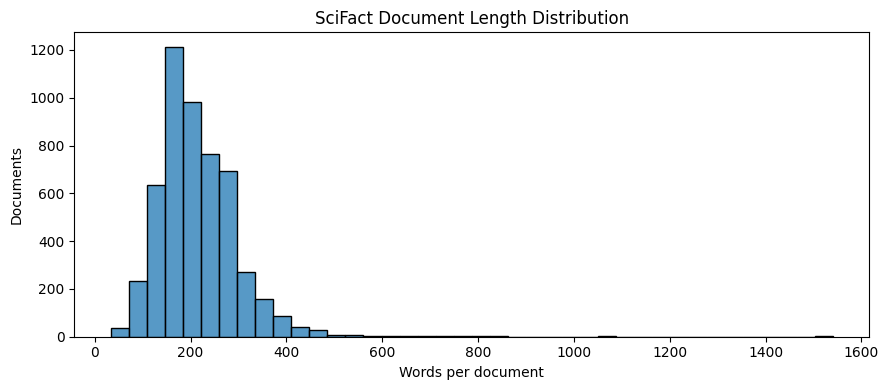

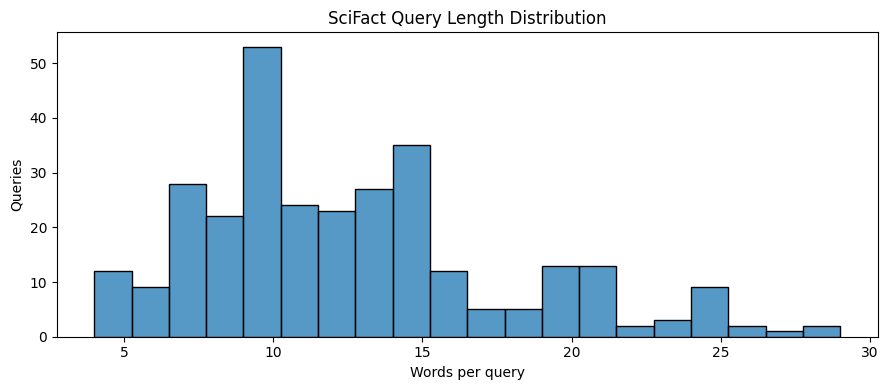

Most frequent terms


,term,count
3,cells,6490
2,cell,4941
12,patients,3727
7,expression,2798
1,cancer,2734
14,results,2476
9,human,2236
13,protein,2224
17,study,2215
0,associated,2136



Example abstract 1: Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion tensor magnetic resonance imaging.
Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical development and result in functional disabilities. A line scan diffusion-weighted magnetic resonance imaging (MRI) sequence with diffusion tensor analysis was applied to measure the apparent diffusion coefficient, to calculate relative anisotropy, and to delineate three-dimensional fiber architecture in cerebral white matter in preterm (n = 17) and full-term infants (n = 7). To assess effects of prematurity on cerebral white matter development, early gestation preterm infants (n = 10) were studied a second time at term. In the central white matter the mean apparent diffusion coefficient...

Example abstract 2: Induction of myelodysplasia by myeloid-derived suppressor cells.
Myelodysplastic syndromes (MDS) are age-dependent stem ce

In [ ]:
df["doc_word_count"] = df["combined_text"].str.split().str.len()
query_df = pd.DataFrame({"query_id": list(queries.keys()), "query": list(queries.values())})
query_df["query_word_count"] = query_df["query"].str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df["doc_word_count"], bins=40, ax=ax)
ax.set_title("SciFact Document Length Distribution")
ax.set_xlabel("Words per document")
ax.set_ylabel("Documents")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(query_df["query_word_count"], bins=20, ax=ax)
ax.set_title("SciFact Query Length Distribution")
ax.set_xlabel("Words per query")
ax.set_ylabel("Queries")
plt.tight_layout()
plt.show()

count_vectorizer = CountVectorizer(stop_words="english", max_features=20)
term_matrix = count_vectorizer.fit_transform(df["combined_text"])
term_counts = np.asarray(term_matrix.sum(axis=0)).ravel()
term_df = (
    pd.DataFrame({"term": count_vectorizer.get_feature_names_out(), "count": term_counts})
    .sort_values("count", ascending=False)
)
print("Most frequent terms")
display(term_df)

for i, row in df.head(3).iterrows():
    print(f"\nExample abstract {i + 1}: {row['title']}\n{row['text'][:700]}...")


## 10. Text Preparation

The dense retrieval input is simply **title + abstract text**. Keeping the title is useful because scientific titles often contain strong topical signals, while the abstract provides the evidence-bearing context.

For readability, we keep both the original title/text columns and a `combined_text` column that is passed to the retrieval models.


In [ ]:
REQUIRED_COLUMNS = ["doc_id", "title", "text", "combined_text"]
assert all(col in df.columns for col in REQUIRED_COLUMNS)

print("Corpus columns:", REQUIRED_COLUMNS)
display(df[REQUIRED_COLUMNS].head(5))


Corpus columns: ['doc_id', 'title', 'text', 'combined_text']


,doc_id,title,text,combined_text
0,4983,Microstructural development of human newborn c...,Alterations of the architecture of cerebral wh...,Microstructural development of human newborn c...
1,5836,Induction of myelodysplasia by myeloid-derived...,Myelodysplastic syndromes (MDS) are age-depend...,Induction of myelodysplasia by myeloid-derived...
2,7912,"BC1 RNA, the transcript from a master gene for...",ID elements are short interspersed elements (S...,"BC1 RNA, the transcript from a master gene for..."
3,18670,The DNA Methylome of Human Peripheral Blood Mo...,DNA methylation plays an important role in bio...,The DNA Methylome of Human Peripheral Blood Mo...
4,19238,The human myelin basic protein gene is include...,Two human Golli (for gene expressed in the oli...,The human myelin basic protein gene is include...


## 11. Baseline: TF-IDF Retrieval

TF-IDF is our transparent lexical baseline. In plain language, it gives more weight to terms that are frequent in a document but less common across the whole collection. A query is converted into the same sparse vector space, and cosine similarity measures how much the query/document vectors point in the same direction.

This is useful because it gives us a strong, understandable baseline before introducing embeddings.


In [ ]:
def build_tfidf_index(texts, max_features=50000):
    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        sublinear_tf=True,
        max_features=max_features
    )
    matrix = vectorizer.fit_transform(texts)
    return vectorizer, matrix


tfidf_vectorizer, tfidf_matrix = build_tfidf_index(df["combined_text"].tolist())
print("TF-IDF matrix shape:", tfidf_matrix.shape)

def tfidf_search(query, top_k=5):
    query_vector = tfidf_vectorizer.transform([query])
    scores = cosine_similarity(query_vector, tfidf_matrix).ravel()
    top_idx = np.argsort(-scores)[:top_k]
    result = df.iloc[top_idx][["doc_id", "title", "text"]].copy()
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    result["similarity"] = scores[top_idx]
    result["abstract_preview"] = result["text"].str.slice(0, 280) + "..."
    return result[["rank", "doc_id", "title", "similarity", "abstract_preview"]]

example_query = "What is the relationship between inflammation and Alzheimer's disease?"
display(tfidf_search(example_query, top_k=5))


TF-IDF matrix shape: (5183, 50000)


,rank,doc_id,title,similarity,abstract_preview
2731,1,17438862,Local neuroinflammation and the progression of...,0.270594,Postmortem immunohistochemical studies have re...
361,2,1967410,Potential use of γ-secretase modulators in the...,0.236914,Although significant progress has occurred in ...
3115,3,20937018,Apolipoprotein E: high-avidity binding to beta...,0.226938,Apolipoprotein E is immunochemically localized...
4222,4,31347396,A rare mutation in UNC5C predisposes to late-o...,0.218528,"We have identified a rare coding mutation, T83..."
3606,5,24530130,Genome-wide association study identifies varia...,0.217006,The gene encoding apolipoprotein E (APOE) on c...


## 12. NLP Embeddings

An embedding converts a text string into a dense numerical vector. The important intuition is that texts with related meaning should tend to occupy nearby locations in vector space.

We use the lightweight pretrained `sentence-transformers/all-MiniLM-L6-v2` model. We are **not** training a transformer and we are not claiming that this model was trained specifically on SciFact. The model is used as a general-purpose semantic encoder; the benchmark tells us how useful it is for this retrieval task.

The model maps text to a 384-dimensional dense vector space.


In [ ]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_CACHE = CACHE_DIR / "document_embeddings.npy"
EMBEDDING_META = CACHE_DIR / "document_embeddings_meta.json"

def load_embedding_model(model_name=MODEL_NAME):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Loading embedding model on:", device)
    return SentenceTransformer(model_name, device=device)

model = load_embedding_model()

def encode_documents(texts, model, batch_size=64):
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    return embeddings.astype("float32")

cache_valid = False
if EMBEDDING_CACHE.exists() and EMBEDDING_META.exists():
    meta = json.loads(EMBEDDING_META.read_text())
    cache_valid = (
        meta.get("model_name") == MODEL_NAME
        and meta.get("doc_count") == len(df)
        and meta.get("doc_ids") == df["doc_id"].tolist()
    )

if cache_valid:
    document_embeddings = np.load(EMBEDDING_CACHE)
    print("Loaded cached document embeddings.")
else:
    document_embeddings = encode_documents(df["combined_text"].tolist(), model, batch_size=64)
    np.save(EMBEDDING_CACHE, document_embeddings)
    EMBEDDING_META.write_text(json.dumps({
        "model_name": MODEL_NAME,
        "doc_count": len(df),
        "embedding_dim": int(document_embeddings.shape[1]),
        "doc_ids": df["doc_id"].tolist()
    }))

print("Embedding matrix shape:", document_embeddings.shape)
print("Embedding dimension:", document_embeddings.shape[1])
print("First 10 values of one embedding:", document_embeddings[0][:10])


Loading embedding model on: cpu


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Embedding matrix shape: (5183, 384)
Embedding dimension: 384
First 10 values of one embedding: [ 0.06467288 -0.10013379 -0.01528093  0.06592723  0.01452199  0.02440255
 -0.05148774  0.01607226  0.02010403  0.02293479]


## 13. Semantic Search

Semantic search follows the same ranking pattern as TF-IDF, but the query is embedded instead of represented as a bag of words. Because the document embeddings are normalised, a dot product is equivalent to cosine similarity.

A larger cosine similarity means the vectors are more aligned in the learned embedding space. It is **not** a probability of relevance and it does not prove scientific correctness.


In [ ]:
def semantic_search(query, top_k=5):
    query_embedding = model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False
    )[0]
    scores = document_embeddings @ query_embedding
    top_idx = np.argsort(-scores)[:top_k]

    result = df.iloc[top_idx][["doc_id", "title", "text"]].copy()
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    result["similarity"] = scores[top_idx]
    result["abstract_preview"] = result["text"].str.slice(0, 280) + "..."
    return result[["rank", "doc_id", "title", "similarity", "abstract_preview"]]

semantic_results = semantic_search(example_query, top_k=5)
display(semantic_results)
# Visualise the top semantic-search scores.
plot_df = semantic_results.sort_values("similarity", ascending=True).copy()
fig = px.bar(
    plot_df,
    x="similarity",
    y="title",
    orientation="h",
    title="Top 5 Semantic Search Results",
    labels={"similarity": "Cosine similarity", "title": "Paper"}
)
fig.show()


,rank,doc_id,title,similarity,abstract_preview
2731,1,17438862,Local neuroinflammation and the progression of...,0.698673,Postmortem immunohistochemical studies have re...
960,2,5035827,Chronic inflammation (inflammaging) and its po...,0.599196,"Human aging is characterized by a chronic, low..."
4311,3,32922179,Alzheimer's disease: the two-hit hypothesis.,0.569357,There are many lines of evidence showing that ...
4785,4,41239107,Immunoproteasome and LMP2 polymorphism in aged...,0.559755,"In this study, we investigated the presence an..."
1314,5,7221410,Alzheimer’s Disease Risk Gene CD33 Inhibits Mi...,0.558051,The transmembrane protein CD33 is a sialic aci...


## 14. Document Similarity

Document-to-document similarity uses exactly the same cosine-similarity idea. Instead of embedding a user query, we take one paper's embedding and compare it with every other paper. We then remove the selected paper itself and keep the nearest neighbours.

Formula:

**cos(A, B) = (A · B) / (||A|| ||B||)**

When the vectors are already normalised, the computation simplifies to a dot product.


In [ ]:
doc_id_to_index = pd.Series(df.index, index=df["doc_id"]).to_dict()

def find_similar_papers(doc_id, top_k=5):
    if doc_id not in doc_id_to_index:
        raise KeyError(f"Unknown doc_id: {doc_id}")

    row_pos = df.index.get_loc(doc_id_to_index[doc_id])
    selected_embedding = document_embeddings[row_pos]
    scores = document_embeddings @ selected_embedding
    scores[row_pos] = -np.inf
    top_idx = np.argsort(-scores)[:top_k]

    result = df.iloc[top_idx][["doc_id", "title", "text"]].copy()
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    result["similarity"] = scores[top_idx]
    result["abstract_preview"] = result["text"].str.slice(0, 280) + "..."
    return result[["rank", "doc_id", "title", "similarity", "abstract_preview"]]

selected_doc_id = df.iloc[0]["doc_id"]
print("Selected paper:", df.loc[df["doc_id"] == selected_doc_id, "title"].iloc[0])
display(find_similar_papers(selected_doc_id, top_k=5))


Selected paper: Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion tensor magnetic resonance imaging.


,rank,doc_id,title,similarity,abstract_preview
259,1,1412089,Diminished performance on neuropsychological t...,0.607456,BACKGROUND Traditional T2 weighted MR imaging ...
268,2,1472815,Alterations of white matter integrity in adult...,0.592371,OBJECTIVE The purpose of our study was to inve...
2963,3,19685306,Orientationally invariant indices of axon diam...,0.563716,This paper proposes and tests a technique for ...
579,4,3205945,Midlife and Late‐Life Vascular Risk Factors an...,0.545230,BACKGROUND Diffusion tensor imaging measures o...
3277,5,22107641,Late-life depression and microstructural abnor...,0.527839,OBJECTIVE The purpose of this study was to det...


## 15. Content-Based Paper Recommendation

A content-based recommendation system recommends items based on the item's own content. Here, the item is a scientific paper and the content representation is its sentence embedding.

There is no user profile and no rating/click history in SciFact, so calling this personalised collaborative filtering would be inaccurate. The recommendation logic is simply: **selected paper → embedding → compare with corpus → rank by cosine similarity → recommend top-k similar papers**.


In [ ]:
def recommend_papers(doc_id, top_k=5):
    return find_similar_papers(doc_id, top_k=top_k)

recommendations = recommend_papers(selected_doc_id, top_k=5)
display(recommendations[["rank", "title", "similarity", "abstract_preview"]])


,rank,title,similarity,abstract_preview
259,1,Diminished performance on neuropsychological t...,0.607456,BACKGROUND Traditional T2 weighted MR imaging ...
268,2,Alterations of white matter integrity in adult...,0.592371,OBJECTIVE The purpose of our study was to inve...
2963,3,Orientationally invariant indices of axon diam...,0.563716,This paper proposes and tests a technique for ...
579,4,Midlife and Late‐Life Vascular Risk Factors an...,0.545230,BACKGROUND Diffusion tensor imaging measures o...
3277,5,Late-life depression and microstructural abnor...,0.527839,OBJECTIVE The purpose of this study was to det...


## 16. Optional Hybrid Retrieval

Hybrid retrieval combines the complementary signals from lexical and semantic search. The implementation stays intentionally simple: both score arrays are min-max normalised per query, then blended.

`hybrid_score = alpha × semantic_score + (1 - alpha) × lexical_score`

We start with `alpha = 0.7` only as a transparent demonstration setting. It is not presented as an optimised hyperparameter; the evaluation section tells us how the chosen setting performs.


In [ ]:
HYBRID_ALPHA = 0.7

def minmax_normalize(scores):
    scores = np.asarray(scores, dtype=float)
    min_v, max_v = np.min(scores), np.max(scores)
    if np.isclose(max_v, min_v):
        return np.zeros_like(scores)
    return (scores - min_v) / (max_v - min_v)

def hybrid_search(query, top_k=5, alpha=HYBRID_ALPHA):
    query_embedding = model.encode(
        [query], convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False
    )[0]
    semantic_scores = document_embeddings @ query_embedding

    query_vector = tfidf_vectorizer.transform([query])
    lexical_scores = cosine_similarity(query_vector, tfidf_matrix).ravel()

    combined = alpha * minmax_normalize(semantic_scores) + (1 - alpha) * minmax_normalize(lexical_scores)
    top_idx = np.argsort(-combined)[:top_k]

    result = df.iloc[top_idx][["doc_id", "title", "text"]].copy()
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    result["hybrid_score"] = combined[top_idx]
    result["semantic_score"] = semantic_scores[top_idx]
    result["lexical_score"] = lexical_scores[top_idx]
    result["abstract_preview"] = result["text"].str.slice(0, 280) + "..."
    return result[["rank", "doc_id", "title", "hybrid_score", "semantic_score", "lexical_score", "abstract_preview"]]

print("Hybrid alpha:", HYBRID_ALPHA)
display(hybrid_search(example_query, top_k=5))


Hybrid alpha: 0.7


,rank,doc_id,title,hybrid_score,semantic_score,lexical_score,abstract_preview
2731,1,17438862,Local neuroinflammation and the progression of...,1.000000,0.698673,0.270594,Postmortem immunohistochemical studies have re...
4311,2,32922179,Alzheimer's disease: the two-hit hypothesis.,0.812680,0.569357,0.197987,There are many lines of evidence showing that ...
3606,3,24530130,Genome-wide association study identifies varia...,0.772788,0.495538,0.217006,The gene encoding apolipoprotein E (APOE) on c...
4785,4,41239107,Immunoproteasome and LMP2 polymorphism in aged...,0.756521,0.559755,0.154487,"In this study, we investigated the presence an..."
3115,5,20937018,Apolipoprotein E: high-avidity binding to beta...,0.752919,0.458157,0.226938,Apolipoprotein E is immunochemically localized...


## 17. Retrieval Evaluation

This is the quantitative heart of the project. We evaluate **TF-IDF**, **semantic embeddings**, and **hybrid retrieval** against the real SciFact test qrels. No labels or scores are fabricated.

We report:

- **Precision@5:** among the first five retrieved documents, how many are relevant on average?
- **Recall@5:** how much of the known relevant set is retrieved in the first five?
- **MRR@10:** how high the first relevant result appears, averaged across queries.
- **NDCG@10:** rewards relevant results appearing near the top while accounting for graded relevance.

The BEIR evaluation utility is used to calculate the metrics.


In [ ]:
EVAL_K = 10

def score_matrix_from_tfidf(query_list):
    query_matrix = tfidf_vectorizer.transform(query_list)
    return cosine_similarity(query_matrix, tfidf_matrix)


def score_matrix_from_semantic(query_list):
    return model.encode(
        query_list,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    ) @ document_embeddings.T


def matrix_to_results(score_matrix, query_ids, doc_ids, top_k=10):
    results = {}

    for row_idx, query_id in enumerate(query_ids):
        row_scores = score_matrix[row_idx]

        # Get indices of the top-k documents.
        k = min(top_k, len(row_scores))
        top_idx = np.argpartition(-row_scores, k - 1)[:k]

        # Sort those documents by descending score.
        top_idx = top_idx[np.argsort(-row_scores[top_idx])]

        results[query_id] = {
            doc_ids[i]: float(row_scores[i])
            for i in top_idx
        }

    return results


query_ids = list(queries.keys())
query_texts = list(queries.values())
doc_ids = df["doc_id"].tolist()


print("Scoring TF-IDF retrieval across all test queries...")
tfidf_score_matrix = score_matrix_from_tfidf(query_texts)


print("Scoring semantic retrieval across all test queries...")
semantic_score_matrix = score_matrix_from_semantic(query_texts)


print("Building hybrid scores...")

hybrid_score_matrix = np.empty_like(semantic_score_matrix)

for i in range(len(query_ids)):
    semantic_scores = minmax_normalize(semantic_score_matrix[i])
    tfidf_scores = minmax_normalize(tfidf_score_matrix[i])

    hybrid_score_matrix[i] = (
        HYBRID_ALPHA * semantic_scores
        + (1 - HYBRID_ALPHA) * tfidf_scores
    )


# Convert score matrices into BEIR-style result dictionaries.
tfidf_results = matrix_to_results(
    tfidf_score_matrix,
    query_ids,
    doc_ids,
    top_k=EVAL_K
)

semantic_results = matrix_to_results(
    semantic_score_matrix,
    query_ids,
    doc_ids,
    top_k=EVAL_K
)

hybrid_results = matrix_to_results(
    hybrid_score_matrix,
    query_ids,
    doc_ids,
    top_k=EVAL_K
)


# ------------------------------------------------------------
# BEIR EVALUATION
# ------------------------------------------------------------

evaluator = EvaluateRetrieval(None, k_values=[5, 10])


def evaluate_retrieval(results):
    """
    Evaluate one retrieval method using the official SciFact qrels.

    BEIR returns dictionaries whose keys are strings such as:
        P@5
        Recall@5
        NDCG@10
        MRR@10
    """

    ndcg, _map, recall, precision = evaluator.evaluate(
        qrels,
        results,
        [5, 10]
    )

    mrr = evaluator.evaluate_custom(
        qrels,
        results,
        [10],
        metric="mrr"
    )

    return {
        "Precision@5": precision["P@5"],
        "Recall@5": recall["Recall@5"],
        "MRR@10": mrr["MRR@10"],
        "NDCG@10": ndcg["NDCG@10"]
    }


print("Evaluating retrieval performance...")

metrics = {
    "TF-IDF": evaluate_retrieval(tfidf_results),
    "Semantic": evaluate_retrieval(semantic_results),
    "Hybrid": evaluate_retrieval(hybrid_results),
}


metrics_df = pd.DataFrame(metrics).T

print(
    "Performance is evaluated empirically using "
    "the SciFact relevance judgements."
)

display(metrics_df.round(4))


# ------------------------------------------------------------
# EVALUATION COMPARISON CHART
# ------------------------------------------------------------

chart_df = (
    metrics_df
    .reset_index()
    .rename(columns={"index": "Method"})
)

chart_long = chart_df.melt(
    id_vars="Method",
    var_name="Metric",
    value_name="Score"
)

fig = px.bar(
    chart_long,
    x="Metric",
    y="Score",
    color="Method",
    barmode="group",
    text_auto=".3f",
    title="SciFact Retrieval Evaluation: TF-IDF vs Semantic vs Hybrid"
)

fig.update_yaxes(range=[0, 1])

fig.show()


# ------------------------------------------------------------
# RETRIEVAL SCORE DISTRIBUTION
# ------------------------------------------------------------

def top_k_score_distribution(score_matrix, method_name, k=10):
    """
    Collect the top-k retrieval scores from every query.
    """

    k = min(k, score_matrix.shape[1])

    top_scores = np.sort(
        score_matrix,
        axis=1
    )[:, -k:].ravel()

    return pd.DataFrame({
        "Method": method_name,
        "Score": top_scores
    })


score_dist_df = pd.concat(
    [
        top_k_score_distribution(
            tfidf_score_matrix,
            "TF-IDF"
        ),
        top_k_score_distribution(
            semantic_score_matrix,
            "Semantic"
        ),
        top_k_score_distribution(
            hybrid_score_matrix,
            "Hybrid"
        )
    ],
    ignore_index=True
)


fig = px.box(
    score_dist_df,
    x="Method",
    y="Score",
    points=False,
    title="Distribution of Top-10 Retrieval Scores per Query"
)

fig.show()

Scoring TF-IDF retrieval across all test queries...
Scoring semantic retrieval across all test queries...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Building hybrid scores...
Evaluating retrieval performance...
Performance is evaluated empirically using the SciFact relevance judgements.


,Precision@5,Recall@5,MRR@10,NDCG@10
TF-IDF,0.1460,0.6758,0.5478,0.5890
Semantic,0.1647,0.7413,0.6068,0.6484
Hybrid,0.1720,0.7766,0.6569,0.6990


## 18. Error Analysis

Metrics tell us *how much* performance changes; error analysis helps us inspect *why*. We will classify a small set of queries into four descriptive groups based on whether the first retrieved document is relevant:

1. TF-IDF relevant / semantic not relevant
2. Semantic relevant / TF-IDF not relevant
3. Both not relevant
4. Both relevant

This is not a proof of causality. The short explanations are grounded in the query, the qrels, and the actual retrieved titles.


In [ ]:
def is_relevant(query_id, doc_id):
    return doc_id in qrels.get(query_id, {}) and qrels[query_id][doc_id] > 0

def top_doc(results, query_id):
    ranked = sorted(results[query_id].items(), key=lambda x: x[1], reverse=True)
    return ranked[0][0]

def first_relevant_doc_ids(query_id, limit=5):
    return [doc_id for doc_id, grade in qrels.get(query_id, {}).items() if grade > 0][:limit]

categories = {
    "TF-IDF relevant / Semantic not relevant": [],
    "Semantic relevant / TF-IDF not relevant": [],
    "Both not relevant": [],
    "Both relevant": [],
}

for qid in query_ids:
    tfidf_top = top_doc(tfidf_results, qid)
    semantic_top = top_doc(semantic_results, qid)
    tfidf_ok = is_relevant(qid, tfidf_top)
    semantic_ok = is_relevant(qid, semantic_top)
    if tfidf_ok and not semantic_ok:
        categories["TF-IDF relevant / Semantic not relevant"].append(qid)
    elif semantic_ok and not tfidf_ok:
        categories["Semantic relevant / TF-IDF not relevant"].append(qid)
    elif tfidf_ok and semantic_ok:
        categories["Both relevant"].append(qid)
    else:
        categories["Both not relevant"].append(qid)

summary = pd.DataFrame({"category": list(categories.keys()), "available_examples": [len(v) for v in categories.values()]})
display(summary)

for category, qids in categories.items():
    if not qids:
        continue
    qid = qids[0]
    tfidf_top = top_doc(tfidf_results, qid)
    semantic_top = top_doc(semantic_results, qid)
    print("\nCATEGORY:", category)
    print("Query:", queries[qid])
    print("Known relevant doc IDs:", first_relevant_doc_ids(qid))
    print("TF-IDF top:", tfidf_top, "->", corpus[tfidf_top].get("title", ""))
    print("Semantic top:", semantic_top, "->", corpus[semantic_top].get("title", ""))
    print("Interpretation: inspect the terminology and document content above; the qrel defines relevance, while the retrieval methods define the ranking.")


,category,available_examples
0,TF-IDF relevant / Semantic not relevant,30
1,Semantic relevant / TF-IDF not relevant,48
2,Both not relevant,119
3,Both relevant,103



CATEGORY: TF-IDF relevant / Semantic not relevant
Query: Activation of PPM1D suppresses p53 function.
Known relevant doc IDs: ['5956380', '4414547']
TF-IDF top: 5956380 -> Exome sequencing identifies somatic gain-of-function PPM1D mutations in brainstem gliomas
Semantic top: 9483851 -> Unravelling mechanisms of p53-mediated tumour suppression
Interpretation: inspect the terminology and document content above; the qrel defines relevance, while the retrieval methods define the ranking.

CATEGORY: Semantic relevant / TF-IDF not relevant
Query: ADAR1 binds to Dicer to cleave pre-miRNA.
Known relevant doc IDs: ['5953485']
TF-IDF top: 5702790 -> Phosphate and R2D2 restrict the substrate specificity of Dicer-2, an ATP-driven ribonuclease.
Semantic top: 5953485 -> ADAR1 Forms a Complex with Dicer to Promote MicroRNA Processing and RNA-Induced Gene Silencing
Interpretation: inspect the terminology and document content above; the qrel defines relevance, while the retrieval methods define the ra

## 19. Embedding Visualisation

A PCA plot gives us a human-friendly picture of a high-dimensional embedding space. PCA compresses the 384-dimensional document vectors into two principal components.

The plot is only a projection: it does **not** preserve every semantic relationship perfectly. Nearby dots can be useful for exploration, but the actual retrieval computation still happens in the original embedding space.


In [ ]:
EMBED_SAMPLE_SIZE = min(750, len(df))
sample_indices = np.linspace(0, len(df) - 1, EMBED_SAMPLE_SIZE, dtype=int)

pca = PCA(n_components=2, random_state=SEED)
embedding_2d = pca.fit_transform(document_embeddings[sample_indices])

explorer_df = df.iloc[sample_indices][["doc_id", "title"]].copy().reset_index(drop=True)
explorer_df["PC1"] = embedding_2d[:, 0]
explorer_df["PC2"] = embedding_2d[:, 1]

fig = px.scatter(
    explorer_df,
    x="PC1",
    y="PC2",
    hover_data={"doc_id": True, "title": True, "PC1": False, "PC2": False},
    title="ResearchRadar: PCA Projection of Scientific Paper Embeddings"
)
fig.update_traces(marker={"size": 7, "opacity": 0.65})
fig.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance shown by PC1+PC2:", pca.explained_variance_ratio_.sum().round(4))


Explained variance ratio: [0.08044608 0.03971213]
Total variance shown by PC1+PC2: 0.1202


## 20. Interactive ResearchRadar Demo

This is the notebook's main user-facing interface. It is intentionally not a full web app: Colab widgets provide enough interactivity to type a research question, inspect results, and select a paper for recommendations.

The interface calls the same functions already introduced earlier, so the demo is not a separate hidden implementation.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

query_input = widgets.Text(
    value="What is the relationship between sleep deprivation and cognitive performance?",
    description="Query:",
    layout=widgets.Layout(width="90%")
)
search_button = widgets.Button(description="Search", button_style="primary")
result_output = widgets.Output()

paper_dropdown = widgets.Dropdown(
    options=[],
    description="Paper:",
    layout=widgets.Layout(width="95%")
)
recommend_button = widgets.Button(description="Recommend similar papers")
recommend_output = widgets.Output()

state = {"search_results": pd.DataFrame()}

def show_search(_):
    with result_output:
        clear_output()
        query = query_input.value.strip()
        if not query:
            print("Please enter a research question.")
            return
        state["search_results"] = semantic_search(query, top_k=5)
        view = state["search_results"].copy()
        view["similarity"] = view["similarity"].round(4)
        display(view[["rank", "doc_id", "title", "similarity", "abstract_preview"]])

        paper_dropdown.options = [(row.title[:80], row.doc_id) for row in state["search_results"].itertuples()]

def show_recommendations(_):
    with recommend_output:
        clear_output()
        if paper_dropdown.value is None:
            print("Run a search and select a paper first.")
            return
        selected = paper_dropdown.value
        print("Selected:", corpus[selected].get("title", ""))
        display(recommend_papers(selected, top_k=5).round(4))

search_button.on_click(show_search)
recommend_button.on_click(show_recommendations)

display(widgets.VBox([query_input, search_button, result_output, widgets.HTML("<hr>"), paper_dropdown, recommend_button, recommend_output]))


## 21. Example Searches

These demo queries are only inputs. The notebook does not fabricate or hard-code the documents returned; every result comes from the real SciFact corpus and the selected retrieval method.

The example list is designed to expose different biomedical/scientific terminology patterns.


In [ ]:
DEMO_QUERIES = [
    "What is the relationship between sleep deprivation and cognitive performance?",
    "Does physical activity reduce the risk of cardiovascular disease?",
    "How does inflammation affect Alzheimer's disease?",
    "What factors influence cancer progression?",
    "Can machine learning improve medical diagnosis?",
    "How are biomarkers used in disease detection?",
    "What is the role of oxidative stress in human disease?",
    "Does diet influence the development of cardiovascular disease?"
]

for i, query in enumerate(DEMO_QUERIES, start=1):
    print(f"{i}. {query}")

print("\nPreview of the first query:")
display(semantic_search(DEMO_QUERIES[0], top_k=5))


1. What is the relationship between sleep deprivation and cognitive performance?
2. Does physical activity reduce the risk of cardiovascular disease?
3. How does inflammation affect Alzheimer's disease?
4. What factors influence cancer progression?
5. Can machine learning improve medical diagnosis?
6. How are biomarkers used in disease detection?
7. What is the role of oxidative stress in human disease?
8. Does diet influence the development of cardiovascular disease?

Preview of the first query:


,rank,doc_id,title,similarity,abstract_preview
1092,1,5912283,Cognitive behavioral therapy vs zopiclone for ...,0.475602,CONTEXT Insomnia is a common condition in olde...
2792,2,17973630,Mindfulness meditation and improvement in slee...,0.473609,IMPORTANCE Sleep disturbances are most prevale...
1981,3,11913139,"The Neurobiology of Sleep: Genetics, cellular ...",0.469991,To appreciate the neural underpinnings of slee...
3029,4,20302714,A twin-study of genetic contributions to morni...,0.421279,Circadian rhythms are associated with the pref...
3071,5,20602517,Melatonin and the circadian regulation of slee...,0.414602,"The endogenous circadian rhythm of melatonin, ..."


## 22. Example Recommendations

For a recommendation demo, we use a paper returned by the semantic search itself. This creates a realistic user journey: **research question → relevant paper → related literature**.

A similarity score is a content-space signal, not a claim that two papers are scientifically equivalent or that one supports the other.


In [ ]:
selected_for_demo = semantic_search(DEMO_QUERIES[0], top_k=1).iloc[0]["doc_id"]
selected_title = corpus[selected_for_demo].get("title", "")
print("Selected paper:", selected_title)
rec_df = recommend_papers(selected_for_demo, top_k=5)
display(rec_df[["rank", "title", "similarity", "abstract_preview"]])

fig = px.bar(
    rec_df.sort_values("similarity"),
    x="similarity",
    y="title",
    orientation="h",
    title="Recommended Papers by Content Similarity"
)
fig.show()


Selected paper: Cognitive behavioral therapy vs zopiclone for treatment of chronic primary insomnia in older adults: a randomized controlled trial.


,rank,title,similarity,abstract_preview
3581,1,"Long-term, nightly benzodiazepine treatment of...",0.648848,"PURPOSE To assess the efficacy, dose stability..."
1021,2,Role of common hypnotics on the phenotypic cau...,0.641809,Hypnotics are contraindicated in obstructive s...
2792,3,Mindfulness meditation and improvement in slee...,0.631959,IMPORTANCE Sleep disturbances are most prevale...
3885,4,Treatments for somnambulism in adults: assessi...,0.578803,"Somnambulism, or sleepwalking, is a parasomnia..."
3176,5,A parasomnia overlap disorder involving sleepw...,0.519519,A series of 33 patients with combined (injurio...


## 23. Findings

This section is intentionally written to populate itself from the measured evaluation table. That prevents accidentally presenting a method as superior before running the benchmark.

After execution, use the metrics to discuss which retrieval methods have which measured Precision@5, Recall@5, MRR@10 and NDCG@10 values, and connect those observations to the error-analysis examples. Avoid claiming general scientific or industry superiority from a single small benchmark.


In [ ]:
def print_findings(metrics_df):
    print("Measured retrieval metrics on the SciFact test qrels:")
    display(metrics_df.round(4))
    print("\nInterpretation guide:")
    print("- Compare the numeric columns directly; different metrics capture different retrieval properties.")
    print("- Use the error-analysis examples to inspect where rankings differ.")
    print("- Treat results as benchmark evidence for this experiment, not as universal superiority claims.")

print_findings(metrics_df)


Measured retrieval metrics on the SciFact test qrels:


,Precision@5,Recall@5,MRR@10,NDCG@10
TF-IDF,0.1460,0.6758,0.5478,0.5890
Semantic,0.1647,0.7413,0.6068,0.6484
Hybrid,0.1720,0.7766,0.6569,0.6990



Interpretation guide:
- Compare the numeric columns directly; different metrics capture different retrieval properties.
- Use the error-analysis examples to inspect where rankings differ.
- Treat results as benchmark evidence for this experiment, not as universal superiority claims.


## 24. Limitations

ResearchRadar is deliberately educational and compact. Important limitations include:

1. SciFact is a relatively small scientific retrieval benchmark compared with modern scholarly indexes.
2. The project uses a pretrained embedding model rather than fine-tuning on SciFact.
3. Semantic similarity does not guarantee scientific correctness.
4. Recommendations are content-based rather than personalised.
5. The corpus contains benchmark abstracts/text rather than a complete modern academic search index.
6. A research assistant should not treat retrieval ranking as evidence that a claim is true.

These limitations are part of the project's story: know what your system can and cannot claim.


## 25. Future Improvements

Useful future extensions should build on the same retrieval foundation rather than adding complexity for its own sake. Realistic next steps are BM25, a scientific-domain embedding model, cross-encoder reranking, citation-graph recommendations, richer metadata filters, personalised signals, larger scientific corpora, multimodal retrieval, and explainable retrieval.


## 26. Conclusion

ResearchRadar demonstrates a complete small-scale IR workflow without hiding the fundamentals behind a framework. It shows how we can move from raw benchmark data to:

**dataset understanding → lexical baseline → embeddings → cosine similarity → ranking → content-based recommendation → visual exploration → quantitative evaluation → error analysis**.
